Dataset loaded successfully!
Shape: (303, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp      

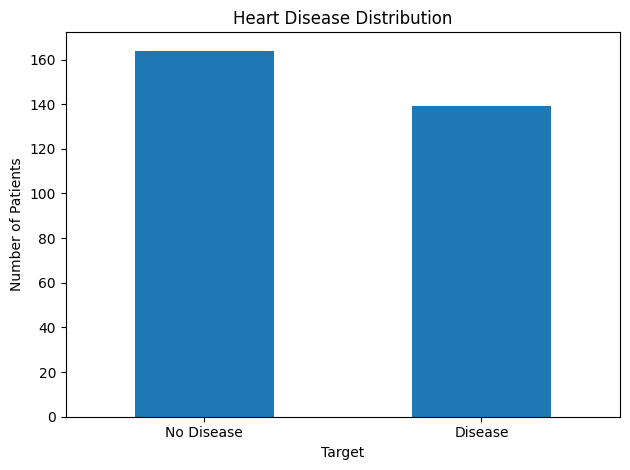

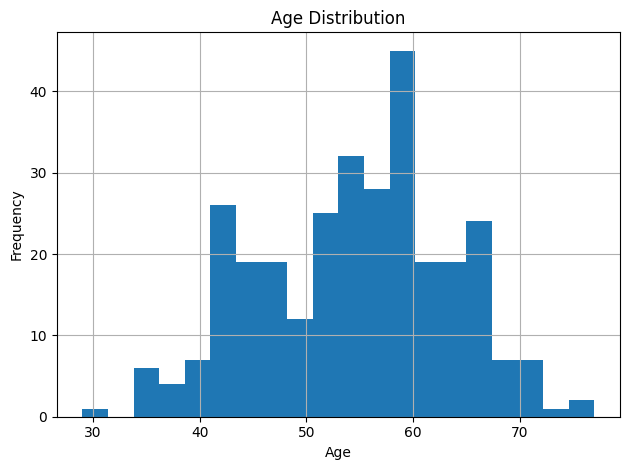

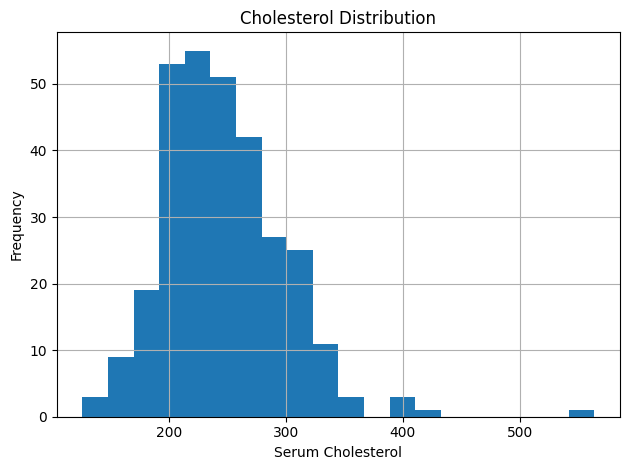

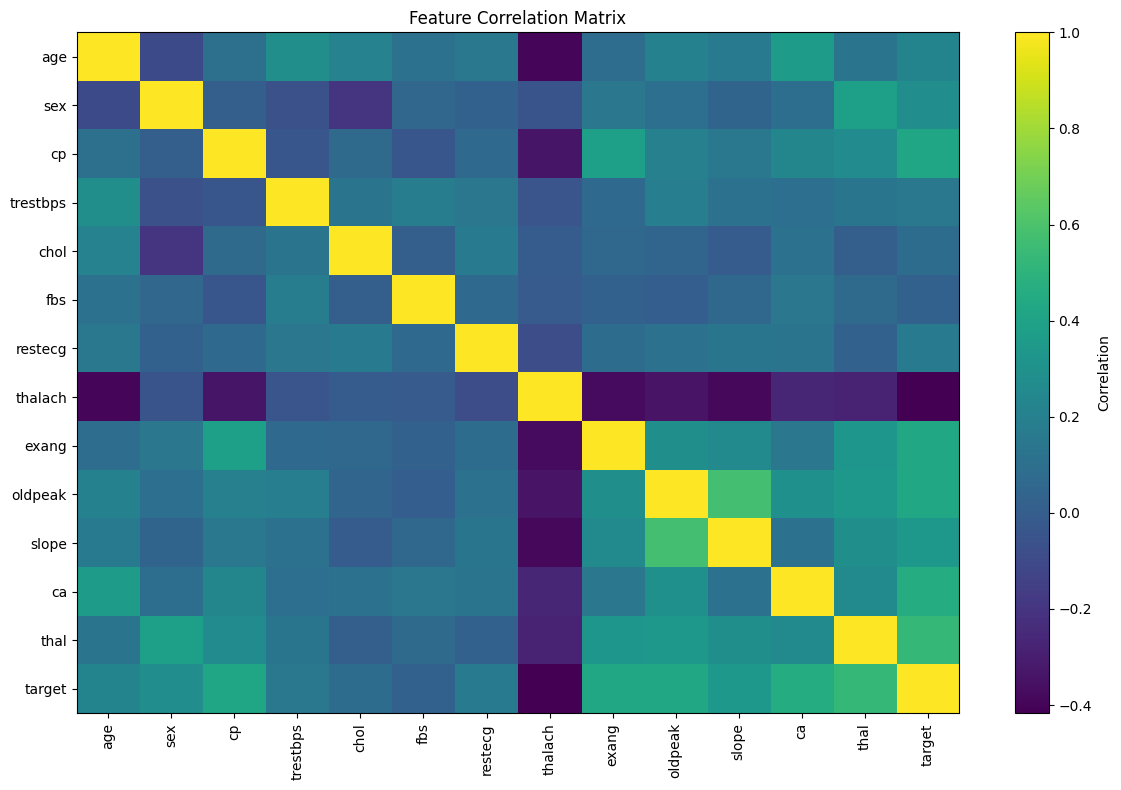


Training samples: 242
Testing samples: 61

Model training completed.

MODEL PERFORMANCE
Accuracy : 0.8689
ROC AUC  : 0.9513

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



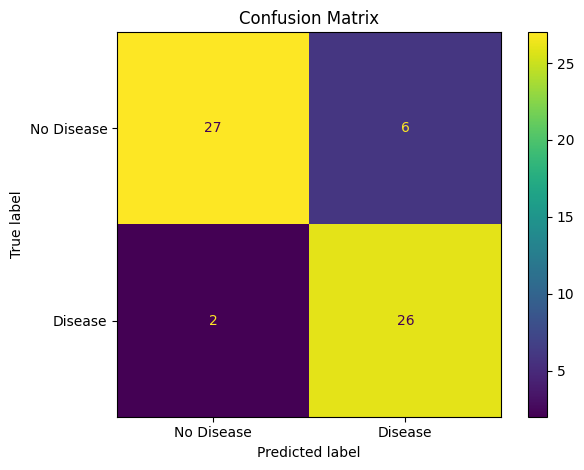

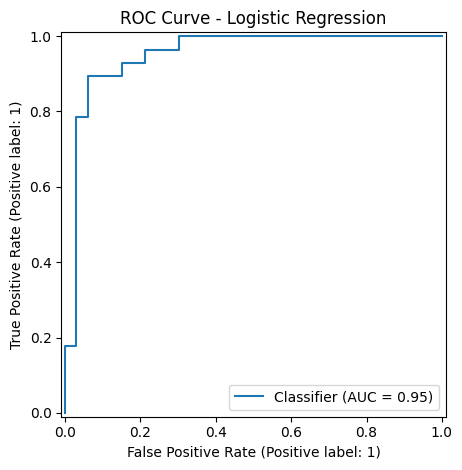

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer #used for handling missing values
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

# ============================================================
# 1. LOAD DATASET FROM UCI
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    url,
    names=columns,
    na_values="?" #for handling missing values it identifies and converts missing-value markers into panda standard missingvalue form.
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)



print("\nFirst 5 rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
print(df.describe())



# Original target:
# 0 = No heart disease
# 1, 2, 3, 4 = Presence of heart disease

df["target"] = (df["target"] > 0).astype(int)

print("\nTarget distribution:")
print(df["target"].value_counts())



# Target distribution
df["target"].value_counts().plot(
    kind="bar",
    title="Heart Disease Distribution"
)

plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1],
    ["No Disease", "Disease"],
    rotation=0
)
plt.tight_layout()
plt.show()



# Age distribution
df["age"].hist(bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



# Cholesterol distribution
df["chol"].hist(bins=20)

plt.title("Cholesterol Distribution")
plt.xlabel("Serum Cholesterol")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()



X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)



scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel training completed.")



y_pred = model.predict(X_test)

# Probability of positive class
y_prob = model.predict_proba(X_test)[:, 1]



accuracy = accuracy_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)



cm = confusion_matrix(
    y_test,
    y_pred
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Disease",
        "Disease"
    ]
)

display.plot()

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Logistic Regression")
plt.tight_layout()
plt.show()